# Exercício 1

Todo número real $x \in [0,1]$ pode ser representado, ou aproximado, por meio de uma **decomposição binária**. Nessa representação, utilizamos apenas os dígitos 0 e 1.

Considerando os primeiros $D$ dígitos binários, podemos escrever

$$
x = \frac{b_1}{2} + \frac{b_2}{2^2} + \frac{b_3}{2^3} + \cdots + \frac{b_D}{2^D},
$$

em que cada $b_i \in \{0,1\}$.

Por exemplo, o número binário $0.101_2$ corresponde, na base decimal, a

$$
0.101_2
=
1\cdot\frac{1}{2}
+
0\cdot\frac{1}{2^2}
+
1\cdot\frac{1}{2^3}
=
0.625.
$$

Assim, ao gerar aleatoriamente uma sequência de zeros e uns, podemos utilizá-la como os dígitos de uma expansão binária e, dessa forma, construir números aleatórios no intervalo $[0,1]$.


Utilizando a função `np.random.choice`, gere uma sequência de tamanho $D$ composta por dígitos 0 ou 1.

1. Utilizando essa sequência e um laço `for`, construa um número aleatório entre 0 e 1 a partir de sua decomposição binária, conforme descrito acima.

2. Utilizando a função `np.arange`, repita o procedimento do item anterior **sem utilizar um laço `for`**. Faça o cálculo por meio de operações vetorizadas, utilizando a multiplicação termo a termo entre os dígitos binários e as respectivas potências de $1/2$.

3. Utilizando o procedimento vetorizado desenvolvido no item 2, gere uma amostra de tamanho $N$ de números aleatórios no intervalo $[0,1]$. Em seguida, gere outra amostra de mesmo tamanho utilizando a função `np.random.uniform`. Compare as distribuições das duas amostras por meio de histogramas e discuta se o procedimento baseado na decomposição binária produz resultados compatíveis com uma distribuição uniforme.

4. Repita o passo 3 várias vezes com diferentes valores de $D$ e comente qual o efeito de aumentar ou diminuir $D$.

In [ ]:
# Importando as bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(847063) #Deixei o meu RA de seed para os resultados não mudarem a cada vez que eu rodar o código

#Utilizando o np.random.choice
D = np.random.choice(2, size=100)

print(D) # Sequência de 0 e 1 gerada

valor = 0
for i in range(len(D)):
  if(D[i] == 1):
    valor += 1/(2**(i+1))

print(valor) # Decimal Obtido

[0 0 0 1 1 1 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 1 1 0 1 1 0 1 0 0 0 1 0 0 0
 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1
 1 0 1 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 1 1 1 0]
0.10993836547007386


In [ ]:
#Repetindo Para D = 500
D = 500

numero_bin = np.random.choice(2, size=D)

resultado = 0

for i in range(0, D):
  resultado += numero_bin[i] * (1/2)**(i+1)

print(resultado)


0.37085397863286174


In [ ]:
# Repetindo para D = 1000
D = 1000
numero_bin = np.random.choice(2, size=D)

resultado = numero_bin * (0.5**np.arange(1,D+1))
print(np.sum(resultado))

0.6560863270308132


In [ ]:
#Utilizando a função np.arange
potencias = np.arange(1,101)
numero_bin = np.random.choice(2, size=100)

np.sum(((1/2)**potencias) * numero_bin)

np.float64(0.7903099226484133)

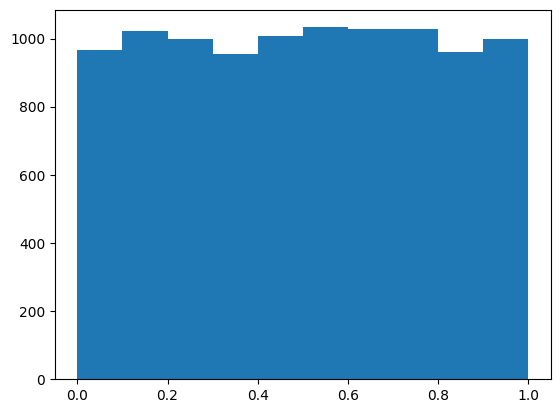

In [ ]:
#Gerando para N = 10_000 e D = 100
N = 10_000
D = 100
valores = []
for i in range(N):
  numero_bin = np.random.choice(2, size=D)
  resultado = np.sum(numero_bin * (0.5**np.arange(1,D+1)))
  valores.append(resultado)

plt.hist(valores)
plt.show()

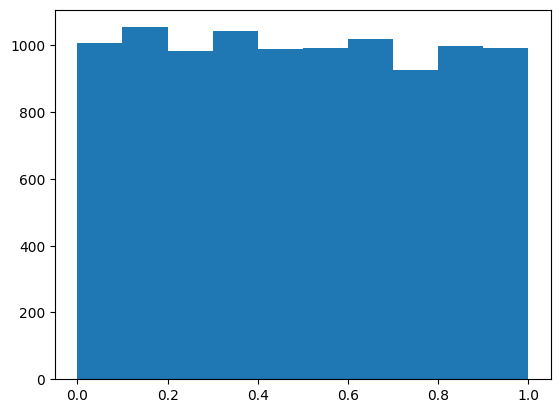

In [ ]:
#Gerando a partir do np.random.uniform para N = 10_000
dados = np.random.uniform(low=0, high=1, size=10000)
plt.hist(dados)
plt.show()

A decomposição binaria conseguiu um resultado muito próximo ao obtido utilizando a função np.random.uniforme e aparenta ter resultados compativeis com uma uniforme

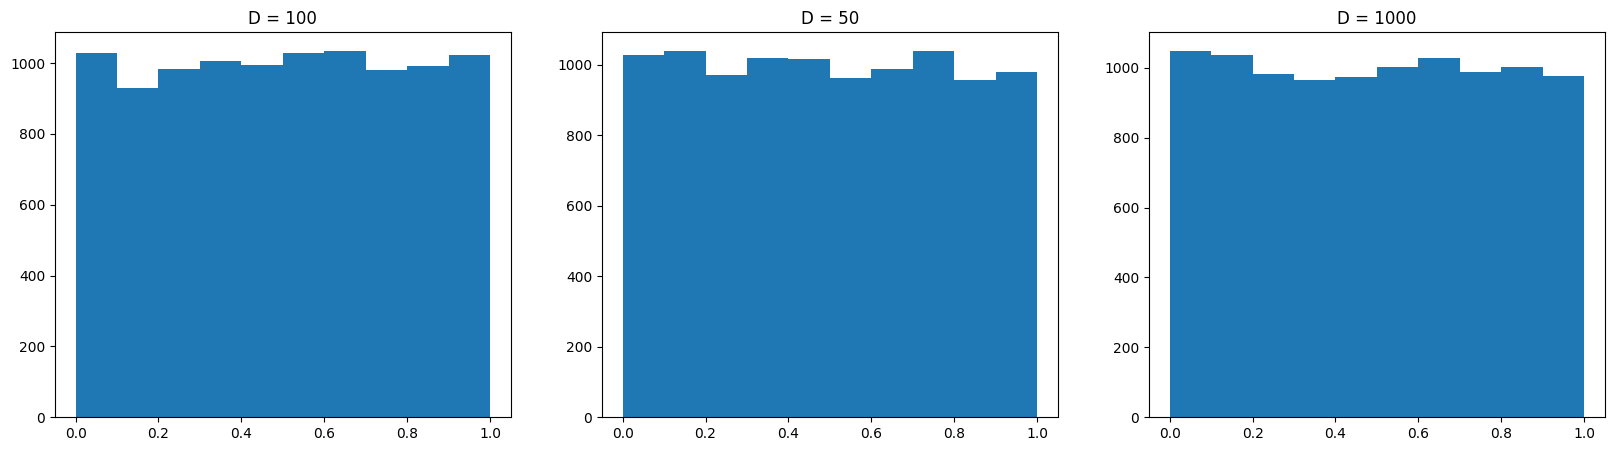

In [ ]:
def binario(D, N):
  valores = []
  for i in range(N):
    numero_bin = np.random.choice(2, size=D)
    resultado = np.sum(numero_bin * (0.5**np.arange(1,D+1)))
    valores.append(resultado)
  return valores

#Gerando com 3 valores de D diferentes
binario_1 = binario(100, 10_000)
binario_2 = binario(50, 10_000)
binario_3 = binario(1_000, 10_000)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].hist(binario_1)
ax[0].set_title("D = 100")

ax[1].hist(binario_2)
ax[1].set_title("D = 50")

ax[2].hist(binario_3)
ax[2].set_title("D = 1000")

plt.show()

Aumentar o D aparenta aumentar a variabilidade, deixando os dados mais uniformemente distribuidos ao longo do intervalo

# Exercício 2 — Simulação de variáveis aleatórias a partir da distribuição uniforme

Apesar de o exercício anterior mostrar como podemos gerar variáveis uniformes em $[0,1]$ a partir de lançamentos de moedas, a partir de agora, e ao longo do curso, assumiremos que o único mecanismo de geração de números aleatórios disponível é a geração de variáveis uniformes no intervalo $[0,1]$.

Neste exercício, vamos utilizar variáveis uniformes para simular algumas das variáveis aleatórias discretas vistas em sala.

A ideia fundamental será transformar uma variável

$$
U \sim \text{Uniforme}(0,1)
$$

em outra variável aleatória por meio de uma função apropriada.

Em todos os itens, considere uma amostra de tamanho $N$.

## 1. Gerando a amostra uniforme

Utilizando `np.random.uniform`, gere uma amostra

$$
U_1,\ldots,U_N
$$

de variáveis aleatórias independentes com distribuição uniforme em $[0,1]$.

Essa será a única fonte de aleatoriedade utilizada nos itens seguintes.

In [ ]:
#Gerando uma uniforme com N = 1000
uniforme = np.random.uniform(low=0, high=1, size=1000)
print(uniforme)

[0.59966697 0.65355357 0.26504151 0.03901626 0.88718061 0.25912092
 0.7260316  0.91321731 0.42956599 0.60434341 0.51253354 0.837099
 0.49839855 0.47429288 0.97817674 0.63121722 0.78426481 0.81063852
 0.29376088 0.07841662 0.05134483 0.95199143 0.40475919 0.6469983
 0.70822347 0.45534791 0.63423423 0.73093405 0.35718266 0.26331141
 0.85158448 0.47198311 0.6486662  0.94781332 0.36063388 0.62826818
 0.1226957  0.09109396 0.85602906 0.0217665  0.53454791 0.25396225
 0.62086106 0.90265555 0.54799038 0.77234661 0.43596075 0.29157819
 0.72219143 0.92434247 0.02013701 0.32914233 0.23920066 0.10896543
 0.91310179 0.28630806 0.57177533 0.12409556 0.87750175 0.39008529
 0.67390411 0.6340147  0.25514845 0.08568856 0.49421463 0.32197507
 0.319257   0.90740246 0.87351716 0.9756221  0.61593129 0.51816819
 0.09097649 0.19307902 0.89628653 0.17766357 0.66316448 0.71859305
 0.90328639 0.64562909 0.8310123  0.86029901 0.14331044 0.36294366
 0.56564491 0.67898064 0.96019931 0.05536843 0.80860891 0.7846645

## 2. Variável Bernoulli

Considere uma variável aleatória Bernoulli com parâmetro $p$, isto é,

$$
P(X=1)=p
\qquad \text{e} \qquad
P(X=0)=1-p.
$$

Utilizando a amostra uniforme gerada no item anterior:

1. Gere uma amostra Bernoulli utilizando um `for` e uma estrutura `if/else`.

2. Crie uma função `f` que transforme valores uniformes em valores `0` ou `1` de acordo com o parâmetro $p$. Em seguida, aplique diretamente essa função à amostra uniforme, isto é, `f(amostra)`.

3. Calcule a média e a variância da amostra Bernoulli obtida e compare-as com os valores teóricos

$$
\mathbb{E}[X]=p
\qquad \text{e} \qquad
\operatorname{Var}(X)=p(1-p).
$$

In [ ]:
def f(amostra):
  p = 0.75
  amostra_final = []
  for i in amostra:
    if(i < p):
      amostra_final.append(1)
    else:
      amostra_final.append(0)

  return amostra_final

resultados = f(uniforme)

media_amostral = np.mean(resultados)
variancia_amostral = np.var(resultados)

p=0.75
comparacao = {'Média amostral': media_amostral,
              'Média': p,
              'Variância Amostral': variancia_amostral,
              'Variância': p*(1-p)}
print(comparacao)

{'Média amostral': np.float64(0.729), 'Média': 0.75, 'Variância Amostral': np.float64(0.19755899999999998), 'Variância': 0.1875}


## 3. Lançamento de um dado justo

Considere um dado justo de seis faces, de modo que

$$
P(X=k)=\frac{1}{6}, \qquad k=1,\ldots,6.
$$

Utilizando a amostra uniforme gerada no item 1:

1. Gere uma amostra de lançamentos do dado utilizando um `for` e uma estrutura `if/elif/else`.

2. Crie uma função `f` que transforme valores uniformes em valores de `1` a `6`. Em seguida, aplique diretamente a função à amostra uniforme, isto é, `f(amostra)`.

3. Você consegue encontrar uma forma mais simples de fazer essa transformação, sem utilizar `if/elif/else`? Pense no que acontece ao multiplicar um valor uniforme por 6 e considerar apenas sua parte inteira.

4. Calcule a frequência relativa de cada face e compare-a com o valor teórico $1/6$.

5. Calcule a média e a variância da amostra e compare-as com os valores teóricos: $\mathbb{E}[X], \operatorname{Var}(X).$ Você pode calcular usando a fórmula $\operatorname{Var}(X) = \mathbb{E}[X^2] - \mathbb{E}[X]^2$.

6. Repita o procedimento anterior para um dado viciado com probabilidades

$$
P(X=1)=0.05,\quad
P(X=2)=0.10,\quad
P(X=3)=0.15,
$$

$$
P(X=4)=0.20,\quad
P(X=5)=0.20,\quad
P(X=6)=0.30.
$$

Construa uma função `f` que transforme a amostra uniforme em lançamentos desse dado. Compare as frequências relativas obtidas com as probabilidades teóricas acima e compare também a média e a variância amostrais com os valores teóricos.


0.155


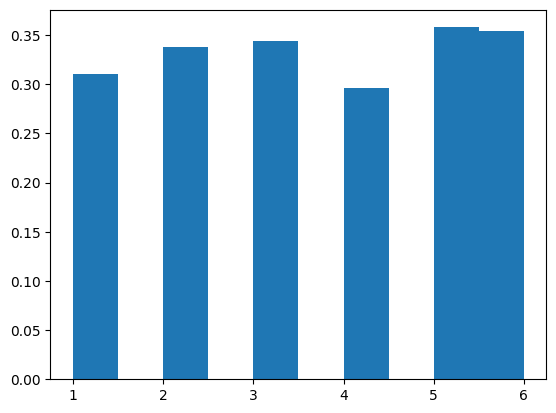

In [ ]:
def f(amostra):
  amostra_final = []
  for i in amostra:
    if(i < 1/6):
      amostra_final.append(1)
    elif(i < 2/6):
      amostra_final.append(2)
    elif(i < 3/6):
      amostra_final.append(3)
    elif(i < 4/6):
      amostra_final.append(4)
    elif(i < 5/6):
      amostra_final.append(5)
    else:
      amostra_final.append(6)
  return amostra_final

dados = f(uniforme)
print(dados.count(1)/len(dados))
plt.hist(dados, density=True) #Histograma dos resultados usando if/elif/else
plt.show()


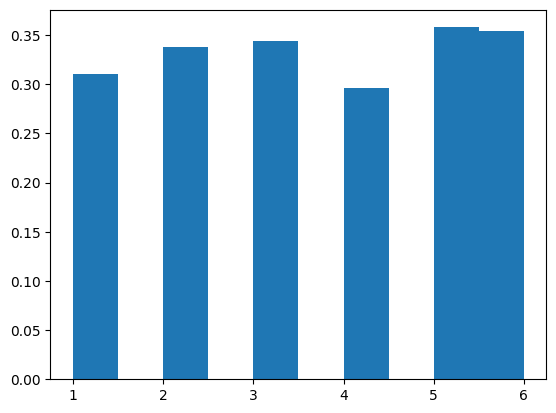

In [ ]:
def f(amostra):
  amostra_final = []
  for i in amostra:
    valor = int(i*6)+1
    amostra_final.append(valor)
  return amostra_final
dados = f(uniforme)
plt.hist(dados, density=True) #Histograma dos resultados multiplicando por 6, observe que aplicando ambas as funções a mesma amostra o resultado obtido é igual, portanto as duas funções estão de fato fazendo a mesma coisa
plt.show()

In [ ]:
faces = []
for i in range(6):
  faces.append(dados.count(i+1)/len(dados))
print(faces) # Frequência relativa

comparacao = []
for i in faces:
  comparacao.append(i/(1/6))
print(comparacao) # Comparação de cada faça com o esperado, fazendo a (frêquencia relativa da face)/(1/6)

[0.155, 0.169, 0.172, 0.148, 0.179, 0.177]
[0.93, 1.0140000000000002, 1.032, 0.888, 1.074, 1.062]


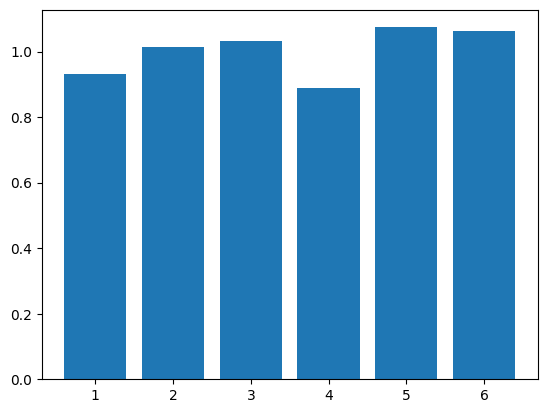

In [ ]:
plt.bar([1,2,3,4,5,6], comparacao) # Gráfico de barras dessa comparação com o valor de 1/6
plt.show()

In [ ]:
media = np.mean(dados)
print(f"média amostral: {media} \nmédia teorica: {1/6 + 2/6 + 3/6 + 4/6 + 5/6 + 1}")
variancia = np.var(dados)
print(f"variância amostral: {variancia} \nvariância teorica: {(1/6 + 4/6 + 9/6 + 16/6 + 25/6 + 36/6) - ((1/6 + 2/6 + 3/6 + 4/6 + 5/6 + 1)**2)}")

média amostral: 3.558 
média teorica: 3.5
variância amostral: 2.9346359999999994 
variância teorica: 2.916666666666668


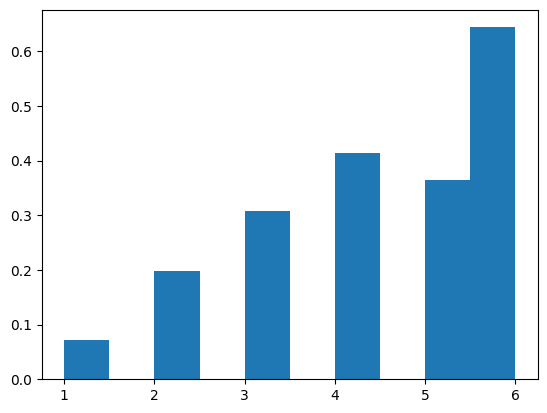

In [ ]:
def f_viciado(amostra):
  amostra_final = []
  for i in amostra:
    if(i < 0.05):
      amostra_final.append(1)
    elif(i < 0.15):
      amostra_final.append(2)
    elif(i < 0.30):
      amostra_final.append(3)
    elif(i < 0.50):
      amostra_final.append(4)
    elif(i < 0.70):
      amostra_final.append(5)
    else:
      amostra_final.append(6)
  return amostra_final

viciados = f_viciado(uniforme)

plt.hist(viciados, density=True)
plt.show()

In [ ]:
teorico_viciadas = [0.05, 0.10, 0.15, 0.20, 0.20, 0.30]
faces_viciadas = []
for i in range(6):
  faces_viciadas.append(viciados.count(i+1)/len(dados))
print(faces_viciadas) #frequência relativa

print([faces_viciadas[i]/teorico_viciadas[i] for i in range(len(faces_viciadas))]) #Comparação de cada faça com o esperado, fazendo a (frêquencia relativa da face)/(frequência teorica)

[0.036, 0.099, 0.154, 0.207, 0.182, 0.322]
[0.7199999999999999, 0.99, 1.0266666666666666, 1.035, 0.9099999999999999, 1.0733333333333335]


In [ ]:
media = np.mean(viciados)
print(f"média amostral: {media} \nmédia teorica: {0.05 + 2*0.10 + 3*0.15 + 4*0.20 + 5*0.20 + 6*0.30}")
variancia = np.var(viciados)
print(f"variância amostral: {variancia} \nvariância teorica: {(0.05 + 4*0.10 + 9*0.15 + 16*0.20 + 25*0.20 + 36*0.30) - ((0.05 + 2*0.10 + 3*0.15 + 4*0.20 + 5*0.20 + 6*0.30)**2)}")

média amostral: 4.366 
média teorica: 4.3
variância amostral: 2.210044 
variância teorica: 2.3099999999999987


## 4. Distribuição Binomial

Podemos interpretar uma variável aleatória binomial pensando em lançamentos de uma moeda. Suponha que lançamos uma moeda $n$ vezes, de forma independente, e que a probabilidade de obter **cara** em cada lançamento seja $p$.

Se contarmos o número total de caras obtidas nesses $n$ lançamentos, esse número segue uma distribuição binomial:

$$
X \sim \mathrm{Binomial}(n,p).
$$

Assim, uma variável binomial nada mais é do que a soma de $n$ variáveis Bernoulli independentes:

$$
X = X_1 + \cdots + X_n,
\qquad
X_i \sim \mathrm{Bernoulli}(p),
$$

onde $X_i=1$ representa uma cara e $X_i=0$ representa uma coroa.

1. Utilizando o procedimento desenvolvido anteriormente para gerar variáveis Bernoulli, gere uma amostra de tamanho $N$ de variáveis com distribuição $\mathrm{Binomial}(n,p)$.

2. Calcule a média e a variância da amostra e compare-as com os valores teóricos

$$
\mathbb{E}[X]=np
\qquad \text{e} \qquad
\operatorname{Var}(X)=np(1-p).
$$

3. Gere uma segunda amostra de tamanho $N$ utilizando `np.random.binomial` com os mesmos parâmetros $n$ e $p$. Compare as duas amostras por meio de histogramas.


{'Média Amostral': np.float64(20.0117), 'Média Teórica': 20.0, 'Variância Amostral': np.float64(16.26796311), 'Variância Teórica': 16.0}


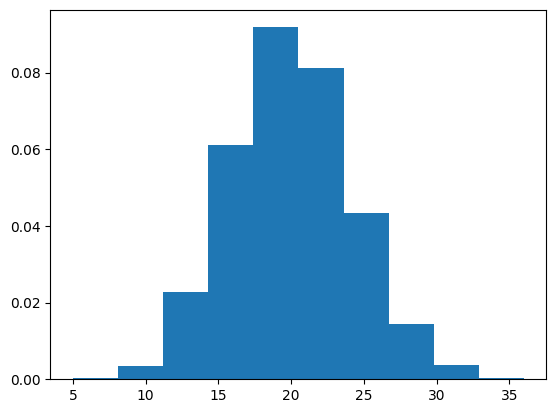

In [ ]:
def binomial(n, p):
  resultados = 0
  for i in range(n):
    if(np.random.uniform(low=0, high=1) < p):
      resultados += 1
  return resultados

def amostra_bin(n, p, N):
  amostras = []
  for i in range(N):
    amostras.append(binomial(n, p))

  return amostras

amostra = amostra_bin(100, 0.2, 10_000)

def comparacao(amostra, n, p):
  comparacao = {'Média Amostral': np.mean(amostra),
                'Média Teórica': n*p,
                'Variância Amostral': np.var(amostra),
                'Variância Teórica': n*p*(1-p)}
  return comparacao

comparacao = comparacao(amostra, 100, 0.2)

print(comparacao)
plt.hist(amostra, density=True)
plt.show()

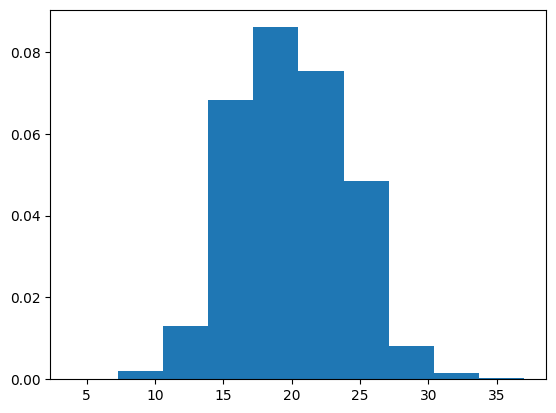

In [ ]:
amostra_2 = np.random.binomial(n=100, p=0.2, size=10_000)
plt.hist(amostra_2, density=True)
plt.show()

## 5. Distribuição Multinomial

A distribuição multinomial é uma generalização da distribuição binomial.

Na distribuição binomial, realizamos $n$ lançamentos de uma moeda e contamos quantas vezes ocorreu um dos dois resultados possíveis. Na distribuição multinomial, fazemos a mesma ideia, mas com $k$ resultados possíveis.

Por exemplo, considere um dado de $k$ lados, em que a face $i$ aparece com probabilidade $p_i$, com

$$
p_1+\cdots+p_k=1.
$$

Após $n$ lançamentos, definimos

$$
X=(X_1,\ldots,X_k),
$$

onde $X_i$ representa o número de vezes que a face $i$ apareceu. Nesse caso,

$$
X \sim \mathrm{Multinomial}(n,p_1,\ldots,p_k),
$$

e

$$
X_1+\cdots+X_k=n.
$$

Considere agora um dado de **4 lados** com probabilidades

$$
P(X=1)=0.10,\qquad
P(X=2)=0.20,\qquad
P(X=3)=0.30,\qquad
P(X=4)=0.40.
$$

1. Utilizando o procedimento desenvolvido anteriormente, realize $n$ lançamentos desse dado e conte quantas vezes cada uma das quatro faces apareceu.

2. Repita esse experimento $N$ vezes, gerando uma amostra de tamanho $N$ de vetores com distribuição multinomial.

3. Para cada face $i$, calcule a média amostral de $X_i$ e compare-a com o valor teórico

$$
\mathbb{E}[X_i]=np_i.
$$

4. Gere uma segunda amostra utilizando `np.random.multinomial` com os mesmos parâmetros e compare os resultados obtidos pelos dois métodos.

5. Verifique que, em cada realização, a soma das contagens das $k$ faces é igual a $n$.

6. Para cada face $i$, calcule a variância amostral de $X_i$ e compare-a com

$$
\operatorname{Var}(X_i)=np_i(1-p_i).
$$

7. Escolha duas faces distintas e calcule a covariância amostral entre suas contagens. Compare-a com

$$
\operatorname{Cov}(X_i,X_j)=-np_ip_j.
$$

Interprete o sinal negativo dessa covariância.

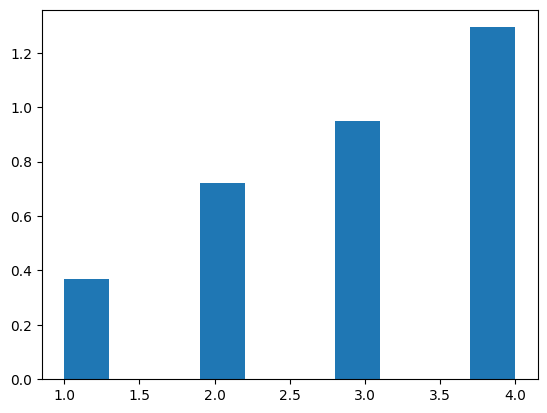

In [ ]:
def f(n):
  amostra_final = []
  for i in range(n):
    valor = np.random.uniform(low=0, high=1)
    if(valor < 0.1):
      amostra_final.append(1)
    elif(valor < 0.3):
      amostra_final.append(2)
    elif(valor < 0.6):
      amostra_final.append(3)
    else:
      amostra_final.append(4)
  return amostra_final

def multi(n, N):
  amostras = []
  for i in range(N):
    amostras.append(f(n))
  return amostras

plt.hist(f(1000), density=True)
plt.show()

In [ ]:
def faces(n, N):
  amostras = multi(n, N)
  f1 = []
  f2 = []
  f3 = []
  f4 = []
  total = []
  for i in amostras:
    f1.append(i.count(1))
    f2.append(i.count(2))
    f3.append(i.count(3))
    f4.append(i.count(4))
    total.append(len(i))

  return [f1, f2, f3, f4 , total]

faces = faces(100, 1_000)
dados = [faces[0], faces[1], faces[2], faces[3]]

def comp_faces(faces, n, N):
  comparacao = {
      "X1": {
          "média amostral": np.mean(faces[0]),
          "média teórica": n*0.1,
          "variância amostral": np.var(faces[0]),
          "variância teórica": n*0.1*(1-0.1)
      },
      "X2": {
          "média amostral": np.mean(faces[1]),
          "média teórica": n*0.2,
          "variância amostral": np.var(faces[1]),
          "variância teórica": n*0.2*(1-0.2)
      },
      "X3": {
          "média amostral": np.mean(faces[2]),
          "média teórica": n*0.3,
          "variância amostral": np.var(faces[2]),
          "variância teórica": n*0.3*(1-0.3)
      },
      "X4": {
          "média amostral": np.mean(faces[3]),
          "média teórica": n*0.4,
          "variância amostral": np.var(faces[3]),
          "variância teórica": n*0.4*(1-0.4)
      }
  }
  return comparacao

print(comp_faces(faces, 100, 1_000))

{'X1': {'média amostral': np.float64(10.155), 'média teórica': 10.0, 'variância amostral': np.float64(9.154974999999999), 'variância teórica': 9.0}, 'X2': {'média amostral': np.float64(19.77), 'média teórica': 20.0, 'variância amostral': np.float64(15.7191), 'variância teórica': 16.0}, 'X3': {'média amostral': np.float64(30.04), 'média teórica': 30.0, 'variância amostral': np.float64(21.108400000000003), 'variância teórica': 21.0}, 'X4': {'média amostral': np.float64(40.035), 'média teórica': 40.0, 'variância amostral': np.float64(23.743775), 'variância teórica': 24.0}}


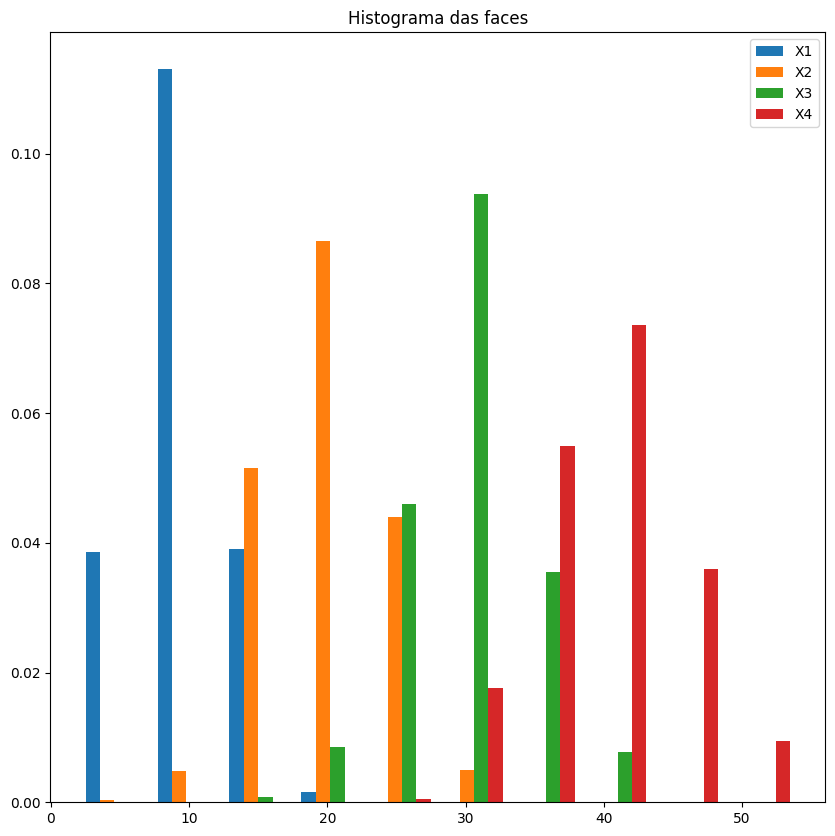

In [ ]:
plt.figure(figsize=(10, 10))
plt.hist(dados, density=True)
plt.legend(["X1", "X2", "X3", "X4"])
plt.title("Histograma das faces")
plt.show()

In [ ]:
# Contagem das k faces
print(faces[4])

[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,

In [ ]:
amostra_multi = np.random.multinomial(n=100, pvals=[0.1, 0.2, 0.3, 0.4], size=1_000)
print(np.mean(amostra_multi, axis=0))

[ 9.883 19.798 30.186 40.133]


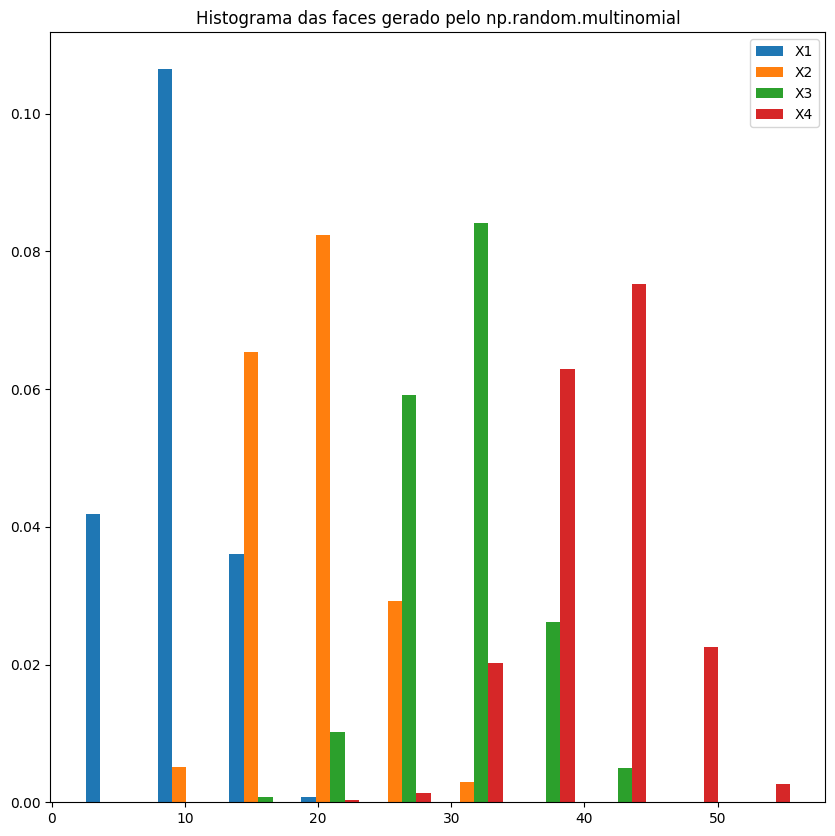

In [ ]:
plt.figure(figsize=(10, 10))
plt.hist(amostra_multi, density=True)
plt.legend(["X1", "X2", "X3", "X4"])
plt.title("Histograma das faces gerado pelo np.random.multinomial")
plt.show()

In [ ]:
print(f"Covariância Amostral entre X1 e X4: {np.cov(faces[0], faces[3])[0][1]}") # Covariancia X1 e X4
print(f"Covariância Teorica entre X1 e X4: {-100*0.1*0.4}")

Covariância Amostral entre X1 e X4: -4.427852852852852
Covariância Teorica entre X1 e X4: -4.0


O sinal negativo dessa covariância é por conta da natureza das faces, tomando n fixo lançamentos, ao aumentar a probabilidade de uma das faces, por consequência a probabilidade de outras faces deve diminuir, ou seja a quantidade de vezes que uma face é observada aumenta mas a de outra diminui, pois não é possivel obter mais de 1 face por lançamento, logo retirar mais de uma em especifico implica que as demais estão em menor quantidade. Por exemplo para um n = 100, obter 80 vezes a 1° face implica que as faces 2, 3 e 4 somadas foram obtidas apenas 20 vezes